# Понижение размерности

In [2]:
import pandas as pd
from math import sqrt

In [3]:
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.model_selection import train_test_split

In [4]:
def test(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    model = Lasso(alpha=0.5)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f'MAE: {mean_absolute_error(y_test, y_pred)}')
    print(f'MSE: {mean_squared_error(y_test, y_pred)}')
    print(f'RMSE: {sqrt(mean_squared_error(y_test, y_pred))}')
    print(f'MAPE: {sqrt(mean_absolute_percentage_error(y_test, y_pred))}')
    print(f'R^2: {model.score(X_test, y_test)}')

In [5]:
data = pd.read_csv("../data/processed_trip_duration.csv")
data.head(5)

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,trip_duration,in_nyc_center?,distance,hour_1,hour_2,...,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,hour_24,is_it_weekday?,is_it_first_vendor?(else 2nd)
0,1,-73.953918,40.778873,-73.963875,40.771164,400,1,1199.769914,1,0,...,0,0,0,0,0,0,0,0,1,0
1,2,-73.988312,40.731743,-73.994751,40.694931,1100,1,4123.945168,0,1,...,0,0,0,0,0,0,0,0,1,1
2,2,-73.997314,40.721458,-73.948029,40.774918,1635,1,7250.435807,0,0,...,0,0,0,0,0,0,0,0,0,0
3,6,-73.961670,40.759720,-73.956779,40.780628,1141,1,2358.286547,0,0,...,0,0,0,0,0,0,0,0,1,0
4,2,-73.993614,40.751884,-73.995422,40.723862,1455,1,3115.641570,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
X = data.drop(labels=["trip_duration"], axis=1)
y = data["trip_duration"]
print(X.shape, y.shape)

(655757, 33) (655757,)


In [61]:
test(X, y)

MAE: 229.4969902141394
MSE: 98975.65289798164
RMSE: 314.60396198710157
MAPE: 0.6545597002442424
R^2: 0.5738489033183003


In [7]:
from sklearn.preprocessing import StandardScaler

In [8]:
scaler = StandardScaler()
X = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)
X.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,in_nyc_center?,distance,hour_1,hour_2,hour_3,...,hour_17,hour_18,hour_19,hour_20,hour_21,hour_22,hour_23,hour_24,is_it_weekday?,is_it_first_vendor?(else 2nd)
0,-0.502944,0.960947,1.175149,0.495931,0.710018,0.160239,-0.653521,4.693443,-0.223545,-0.235022,...,-0.229354,-0.219163,-0.192173,-0.149607,-0.138516,-0.100213,-0.096095,-0.162843,0.631163,-0.933511
1,0.259328,-0.418388,-0.976437,-0.751979,-2.339383,0.160239,0.589853,-0.213063,4.473379,-0.235022,...,-0.229354,-0.219163,-0.192173,-0.149607,-0.138516,-0.100213,-0.096095,-0.162843,0.631163,1.071225
2,0.259328,-0.779439,-1.445937,1.136383,0.860168,0.160239,1.919252,-0.213063,-0.223545,4.254921,...,-0.229354,-0.219163,-0.192173,-0.149607,-0.138516,-0.100213,-0.096095,-0.162843,-1.584377,-0.933511
3,3.308414,0.650076,0.300757,0.782700,1.088599,0.160239,-0.160914,-0.213063,-0.223545,-0.235022,...,-0.229354,-0.219163,-0.192173,-0.149607,-0.138516,-0.100213,-0.096095,-0.162843,0.631163,-0.933511
4,0.259328,-0.631041,-0.056941,-0.779114,-1.182125,0.160239,0.161117,-0.213063,-0.223545,-0.235022,...,-0.229354,-0.219163,-0.192173,-0.149607,-0.138516,-0.100213,-0.096095,-0.162843,-1.584377,-0.933511


In [64]:
test(X, y)

MAE: 227.6545458598296
MSE: 97429.83304462828
RMSE: 312.1375226476757
MAPE: 0.6495394263828014
R^2: 0.5805046091054384


## 1. Отбор признаков

### Variance Threshold

In [65]:
from sklearn.feature_selection import VarianceThreshold

In [66]:
vt = VarianceThreshold(1)
X_vt = vt.fit_transform(X)
X_vt.shape

(655757, 21)

In [67]:
X_vt = pd.DataFrame(X_vt, columns=vt.get_feature_names_out())
X_vt.head()

,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,in_nyc_center?,distance,hour_1,hour_2,hour_4,hour_7,...,hour_9,hour_10,hour_11,hour_13,hour_16,hour_18,hour_20,hour_21,hour_22,hour_23
0,-0.502944,0.960947,1.175149,0.495931,0.160239,-0.653521,4.693443,-0.223545,-0.222588,-0.260143,...,-0.227539,-0.220611,-0.247768,-0.225235,-0.223266,-0.219163,-0.149607,-0.138516,-0.100213,-0.096095
1,0.259328,-0.418388,-0.976437,-0.751979,0.160239,0.589853,-0.213063,4.473379,-0.222588,-0.260143,...,-0.227539,-0.220611,-0.247768,-0.225235,-0.223266,-0.219163,-0.149607,-0.138516,-0.100213,-0.096095
2,0.259328,-0.779439,-1.445937,1.136383,0.160239,1.919252,-0.213063,-0.223545,-0.222588,-0.260143,...,-0.227539,-0.220611,-0.247768,-0.225235,-0.223266,-0.219163,-0.149607,-0.138516,-0.100213,-0.096095
3,3.308414,0.650076,0.300757,0.782700,0.160239,-0.160914,-0.213063,-0.223545,4.492607,-0.260143,...,-0.227539,-0.220611,-0.247768,-0.225235,-0.223266,-0.219163,-0.149607,-0.138516,-0.100213,-0.096095
4,0.259328,-0.631041,-0.056941,-0.779114,0.160239,0.161117,-0.213063,-0.223545,-0.222588,-0.260143,...,-0.227539,-0.220611,-0.247768,-0.225235,-0.223266,-0.219163,-0.149607,-0.138516,-0.100213,-0.096095


In [68]:
test(X_vt, y)

MAE: 235.63332215655913
MSE: 103309.89169988756
RMSE: 321.4185615360251
MAPE: 0.6610320261687538
R^2: 0.5551873379268963


### SelectKBest

In [69]:
from sklearn.feature_selection import SelectKBest

In [70]:
skb = SelectKBest(k=3)
X_skb = skb.fit_transform(X, y)
X_skb = pd.DataFrame(X_skb, columns=skb.get_feature_names_out())
X_skb.head()

,pickup_longitude,dropoff_longitude,distance
0,0.960947,0.495931,-0.653521
1,-0.418388,-0.751979,0.589853
2,-0.779439,1.136383,1.919252
3,0.650076,0.782700,-0.160914
4,-0.631041,-0.779114,0.161117


In [71]:
test(X_skb, y)

MAE: 244.56619580917746
MSE: 110063.69649666989
RMSE: 331.7584912201493
MAPE: 0.6743500924536169
R^2: 0.5261080518939005


### RFE (рекурсивный отбор признаков)

In [72]:
from sklearn.feature_selection import RFE
from sklearn.tree import DecisionTreeRegressor

In [73]:
sample = data.sample(frac=0.1, random_state=42)
X = sample.drop(labels=["trip_duration"], axis=1)
y = sample["trip_duration"]

In [74]:
tree = DecisionTreeRegressor().fit(X, y)

In [75]:
rfe = RFE(estimator=tree, n_features_to_select=2, step=1).fit(X, y)
X_rfe = pd.DataFrame(rfe.transform(X), columns=rfe.get_feature_names_out())
X_rfe

,dropoff_latitude,distance
0,40.756096,978.370553
1,40.719841,2492.484617
2,40.761528,1349.913551
3,40.723251,1972.968905
4,40.774590,1781.418739
...,...,...
65571,40.772434,1057.770758
65572,40.744526,1103.590079
65573,40.696724,2835.481944
65574,40.739780,837.722239


In [76]:
test(X_rfe, y)

MAE: 247.63098938178334
MSE: 111390.41434780222
RMSE: 333.75202523400844
MAPE: 0.6829507013182712
R^2: 0.5215585240293452


## 2. Выделение признаков

### PCA 

In [77]:
from sklearn.decomposition import PCA

In [78]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X, y)
X_pca.shape

(65576, 2)

In [16]:
import matplotlib.pyplot as plt

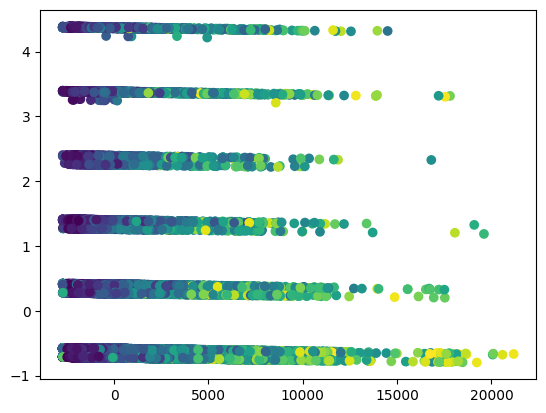

In [80]:
plt.scatter(X_pca[:,0], X_pca[:,1], c=y)

In [81]:
sum(pca.explained_variance_ratio_)

0.9999997457624211

In [82]:
test(X_pca, y)

MAE: 248.69841836479063
MSE: 112075.2639794594
RMSE: 334.77643880574897
MAPE: 0.684762227955925
R^2: 0.5186169740718691


In [83]:
pca_2 = PCA(n_components=3)
X_pca_2 = pca_2.fit_transform(X, y)

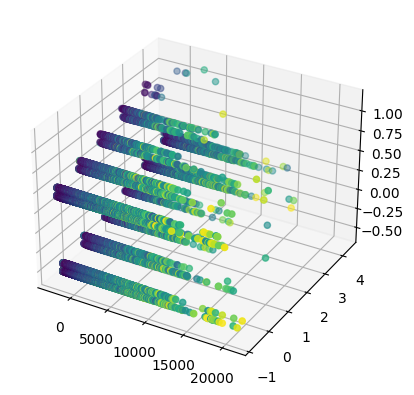

In [84]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.scatter(X_pca_2[:,0], X_pca_2[:,1], X_pca_2[:,2], c=y)

In [85]:
test(X_pca_2, y)

MAE: 248.69568467415647
MSE: 112074.14426630952
RMSE: 334.77476647189155
MAPE: 0.6847502960187416
R^2: 0.5186217834373359


### Kernel PCA

In [12]:
from sklearn.decomposition import KernelPCA

In [13]:
kernels = [
    {'name': 'poly', 'params': {'gamma': 3, 'degree': 3, 'coef0': 1}},
    {'name': 'rbf', 'params': {'gamma': 0.05}},
    {'name': 'sigmoid', 'params': {'gamma': 0.1, 'coef0': 1}}
]

In [14]:
sample = data.sample(frac=0.01, random_state=42)
X = sample.drop(labels=["trip_duration"], axis=1)
y = sample["trip_duration"]


--- Kernel: POLY ---


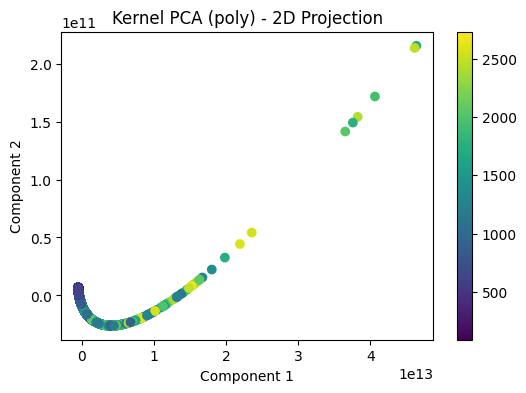

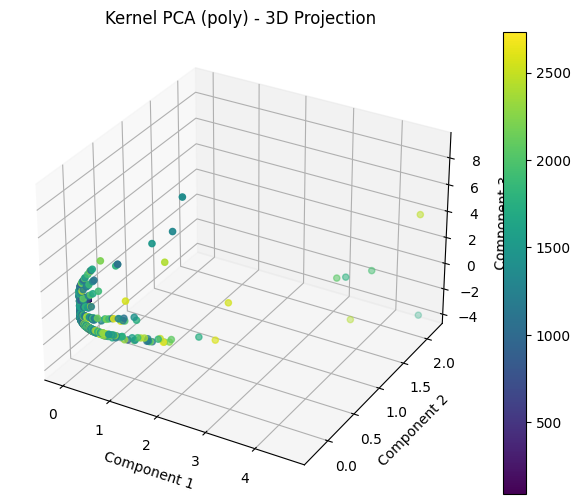

Результаты для 2D:
MAE: 266.0565044768483
MSE: 126771.49598966961
RMSE: 356.0498504278153
MAPE: 0.7191257248075954
R^2: 0.4271162478533371
Результаты для 3D:
MAE: 266.06591895010985
MSE: 126765.92752621128
RMSE: 356.0420305612966
MAPE: 0.7191354713205186
R^2: 0.42714141188737176

--- Kernel: RBF ---


d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:678: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.128e+05, tolerance: 1.206e+05
  model = cd_fast.enet_coordinate_descent(


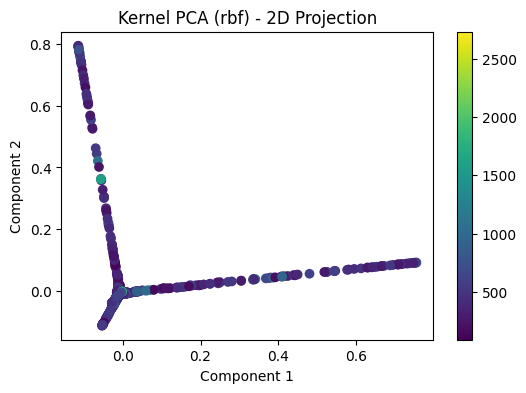

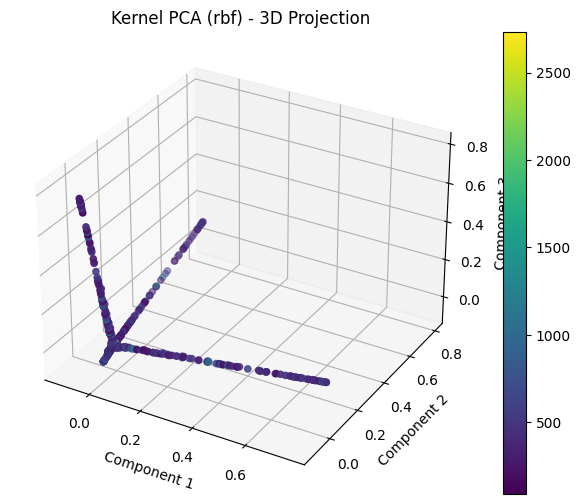

Результаты для 2D:
MAE: 370.6269893671456
MSE: 221024.36627477684
RMSE: 470.1322859310737
MAPE: 0.8877095990506572
R^2: 0.0011850276054907738
Результаты для 3D:
MAE: 369.5594930865436
MSE: 220344.46676045714
RMSE: 469.40863515753216
MAPE: 0.8861135950921921
R^2: 0.0042575115405064645

--- Kernel: SIGMOID ---


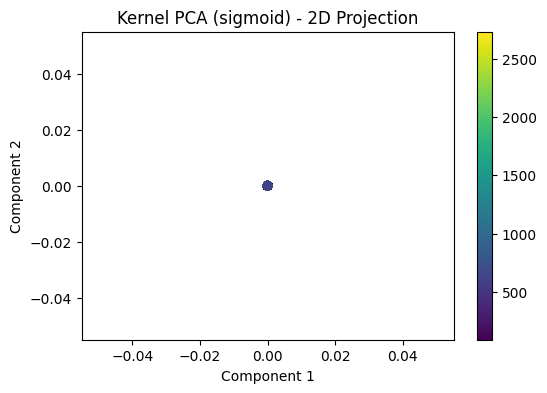

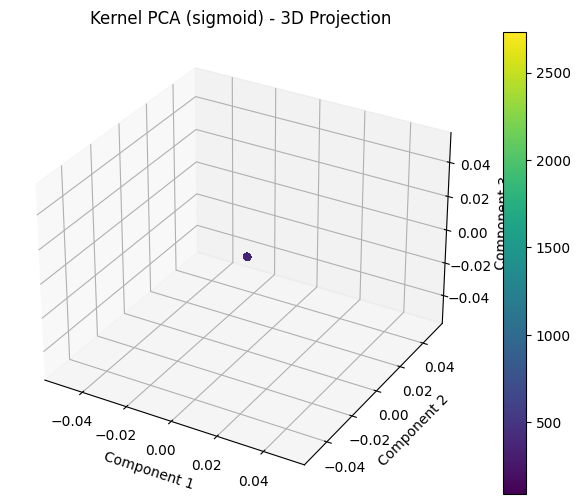

Результаты для 2D:
MAE: 371.2179988469728
MSE: 221346.0064116198
RMSE: 470.4742356512414
MAPE: 0.8882102385527995
R^2: -0.00026847270226437736
Результаты для 3D:
MAE: 371.2179988469728
MSE: 221346.0064116198
RMSE: 470.4742356512414
MAPE: 0.8882102385527995
R^2: -0.00026847270226437736


In [17]:
for kernel_config in kernels:
    kernel_name = kernel_config['name']
    params = kernel_config['params']
    
    print(f"\n--- Kernel: {kernel_name.upper()} ---")
    
    kpca_2d = KernelPCA(n_components=2, kernel=kernel_name, **params)
    X_kpca_2d = kpca_2d.fit_transform(X)
    
    plt.figure(figsize=(6, 4))
    plt.scatter(X_kpca_2d[:, 0], X_kpca_2d[:, 1], c=y, cmap='viridis')
    plt.title(f'Kernel PCA ({kernel_name}) - 2D Projection')
    plt.xlabel('Component 1')
    plt.ylabel('Component 2')
    plt.colorbar()
    plt.show()
    
    kpca_3d = KernelPCA(n_components=3, kernel=kernel_name, **params)
    X_kpca_3d = kpca_3d.fit_transform(X)
    
    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(X_kpca_3d[:, 0], X_kpca_3d[:, 1], X_kpca_3d[:, 2], c=y, cmap='viridis')
    plt.colorbar(scatter)
    ax.set_title(f'Kernel PCA ({kernel_name}) - 3D Projection')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.show()
    
    print("Результаты для 2D:")
    test(X_kpca_2d, y)
    
    print("Результаты для 3D:")
    test(X_kpca_3d, y)

## 2.2 Нелиненые методы выделения призанков

In [9]:
sample = data.sample(frac=0.01, random_state=42)
X = data.drop(labels=["trip_duration"], axis=1)
y = data["trip_duration"]

### t-SNE

In [10]:
from sklearn.manifold import TSNE

In [11]:
tsne = TSNE(n_components=2, n_jobs=-1)

In [12]:
# X_tsne = tsne.fit_transform(X)

In [13]:
# plt.scatter(X_tsne[:,0], X_tsne[:,1], c=y)

In [14]:
# test(X_tsne, y)

### Isomap

In [15]:
from sklearn.manifold import Isomap

In [ ]:
isomap = Isomap(n_components=2)
X_isomap = isomap.fit_transform(X)

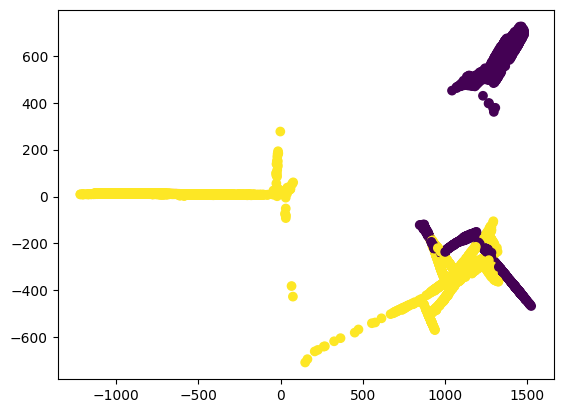

In [ ]:
plt.scatter(X_isomap[:,0], X_isomap[:,1], c=y)

In [ ]:
test(X_isomap, y)

              precision    recall  f1-score   support

           0       0.99      1.00      0.99       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



### UMAP

In [ ]:
import umap

In [ ]:
umap_configs = [
    {'n_neighbors': 15, 'min_dist': 0.1, 'metric': 'euclidean'},
    {'n_neighbors': 5, 'min_dist': 0.01, 'metric': 'euclidean'},
    {'n_neighbors': 50, 'min_dist': 0.5, 'metric': 'euclidean'},
    {'n_neighbors': 15, 'min_dist': 0.1, 'metric': 'cosine'}
]

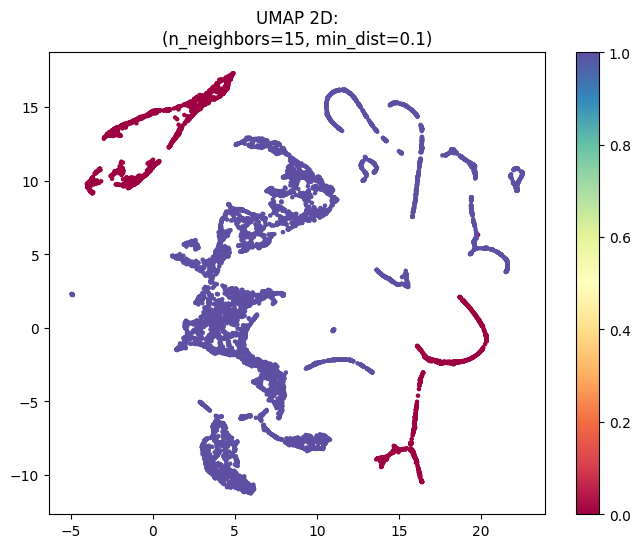

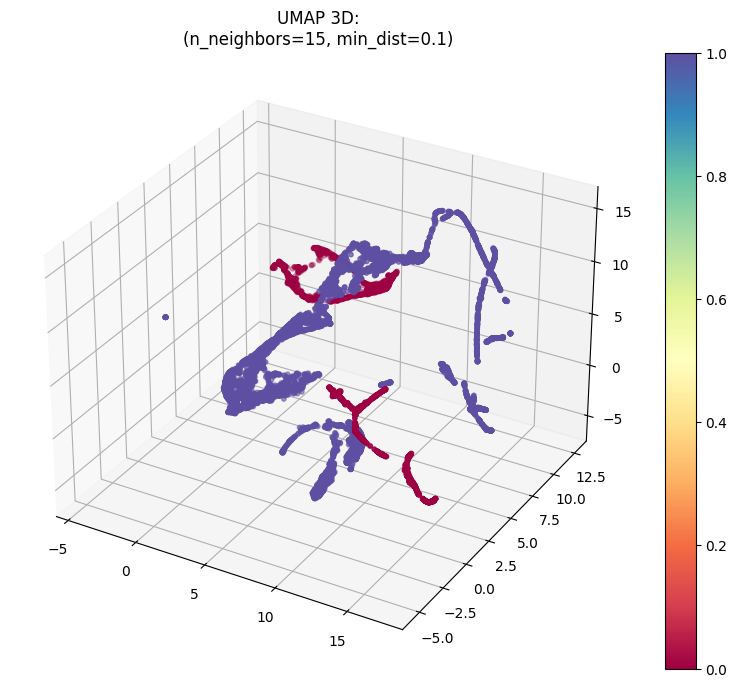

2D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063

3D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


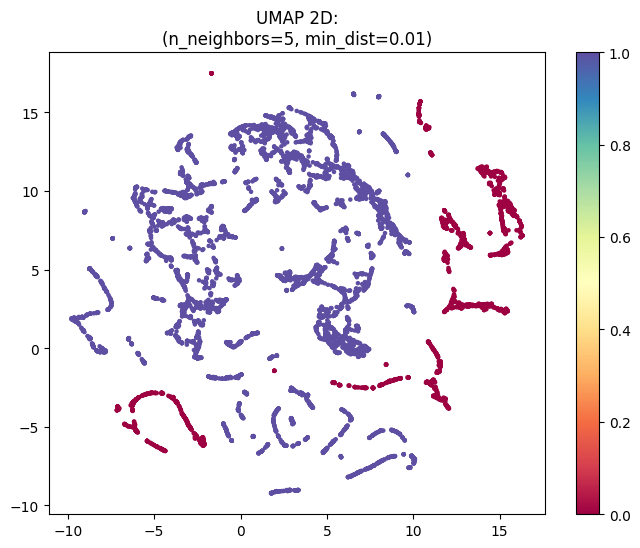

d:\Programming\ML-labs\.venv\Lib\site-packages\sklearn\manifold\_spectral_embedding.py:301: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


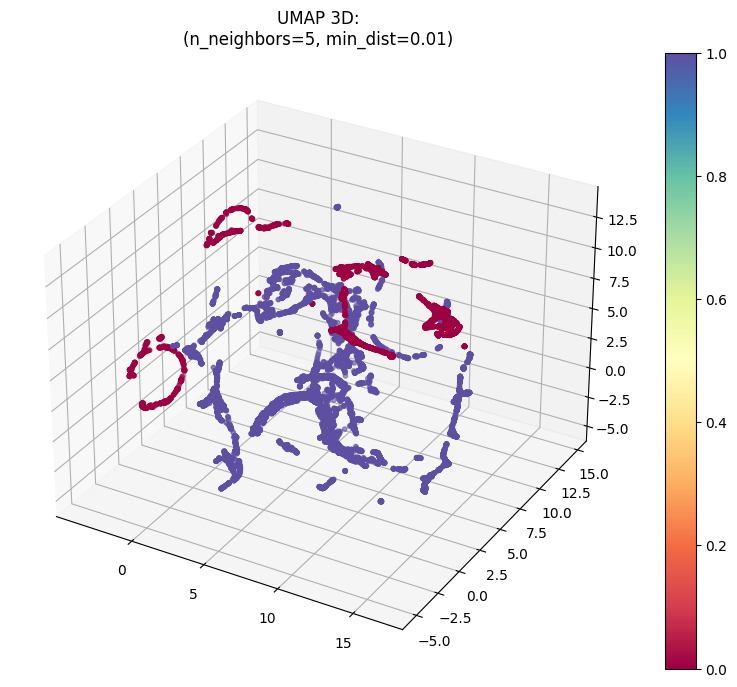

2D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063

3D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



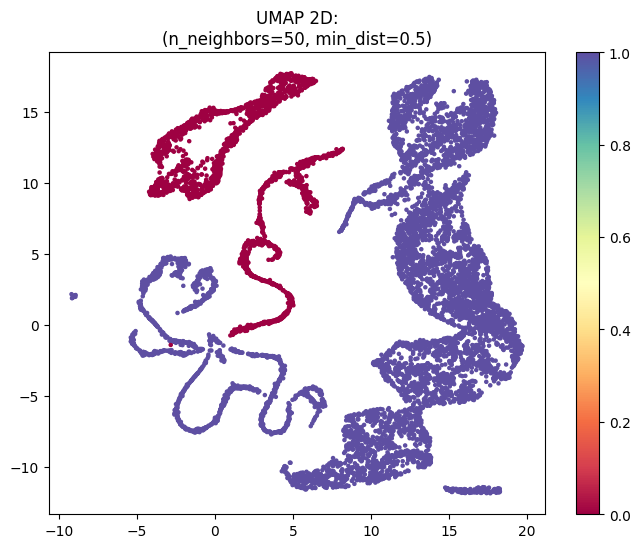

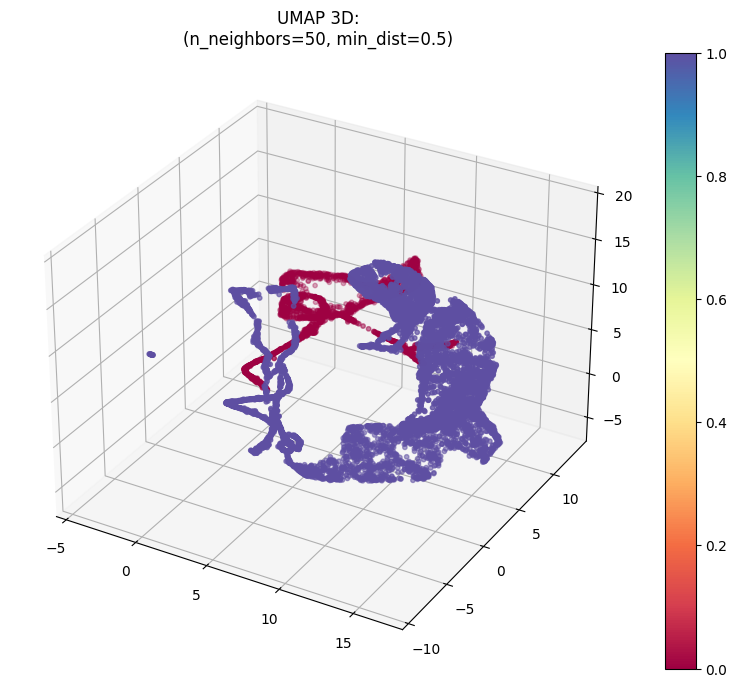

2D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063

3D results:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       463
           1       1.00      1.00      1.00      1600

    accuracy                           1.00      2063
   macro avg       1.00      1.00      1.00      2063
weighted avg       1.00      1.00      1.00      2063



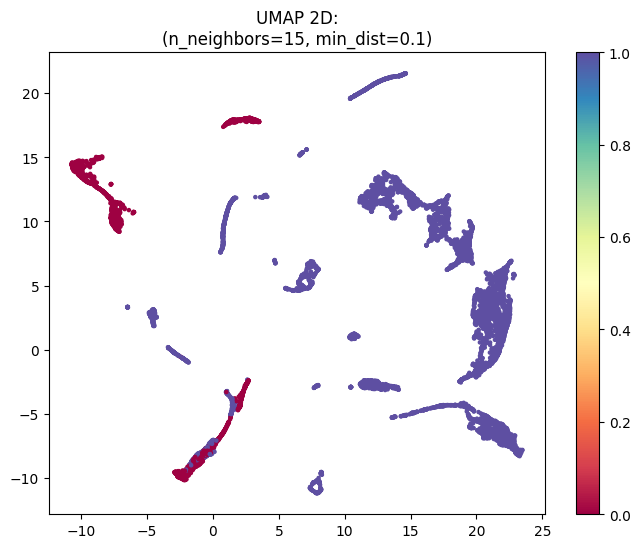

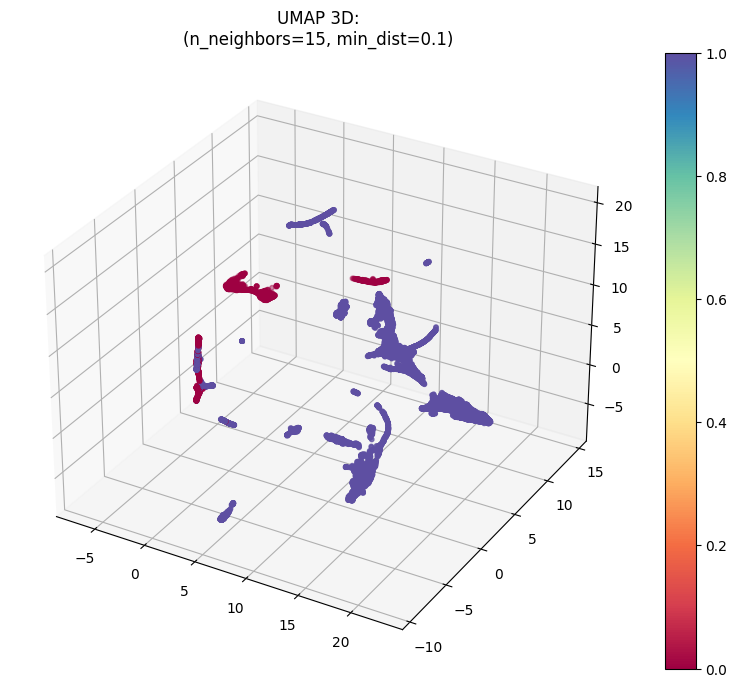

2D results:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97       463
           1       0.99      0.99      0.99      1600

    accuracy                           0.99      2063
   macro avg       0.98      0.98      0.98      2063
weighted avg       0.99      0.99      0.99      2063

3D results:
              precision    recall  f1-score   support

           0       0.97      0.97      0.97       463
           1       0.99      0.99      0.99      1600

    accuracy                           0.99      2063
   macro avg       0.98      0.98      0.98      2063
weighted avg       0.99      0.99      0.99      2063



In [ ]:
for config in umap_configs:

    reducer_2d = umap.UMAP(n_components=2, **config)
    embedding_2d = reducer_2d.fit_transform(X)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(embedding_2d[:, 0], embedding_2d[:, 1], c=y, cmap='Spectral', s=5)
    plt.title(f"UMAP 2D:\n(n_neighbors={config['n_neighbors']}, min_dist={config['min_dist']})")
    plt.colorbar()
    plt.show()
    
    reducer_3d = umap.UMAP(n_components=3, **config)
    embedding_3d = reducer_3d.fit_transform(X)
    
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    sc = ax.scatter(embedding_3d[:, 0], embedding_3d[:, 1], embedding_3d[:, 2], 
                   c=y, cmap='Spectral', s=10)
    plt.colorbar(sc)
    ax.set_title(f"UMAP 3D:\n(n_neighbors={config['n_neighbors']}, min_dist={config['min_dist']})")
    plt.show()
    
    print("2D results:")
    test(embedding_2d, y)
    
    print("3D results:")
    test(embedding_3d, y)